# Drone Rendu

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools
from networkx.algorithms.matching import max_weight_matching
import random
import pickle
import copy

#### I. importer Montréal

In [4]:
def import_G(filename):    
    with open(filename, 'rb') as f:
        G = pickle.load(f).to_undirected()
    return G
    
G = import_G("../database/maps/montreal.gpickle")
G_aug = import_G("../database/eulerized_maps/montreal_aug.gpickle")

#### II. Enneiger

In [5]:
def snowize(G, p = 0.5):
    for u, v in G.edges():
        for key in G[u][v]:
            if (random.random() <= p):
                G[u][v][key]['snow'] = 1
            else:
                G[u][v][key]['snow'] = 0
    return G

G = snowize(G, 0.1)
G_bis = nx.MultiGraph(G)

#### III. Trouver la neige et rendre une liste

In [8]:
def snow_roads(G_aug, G_bis):
    circuit = list(nx.eulerian_circuit(G_aug))
    edges = []
    for i, (u, v) in enumerate(circuit):
        for key in G_bis[u][v]:
            if G_bis[u][v][key]['snow']:
                edges.append((u, v, key))

    return edges

snow_edges = snow_roads(G_aug, G_bis)

#### IV. Afficher Montréal

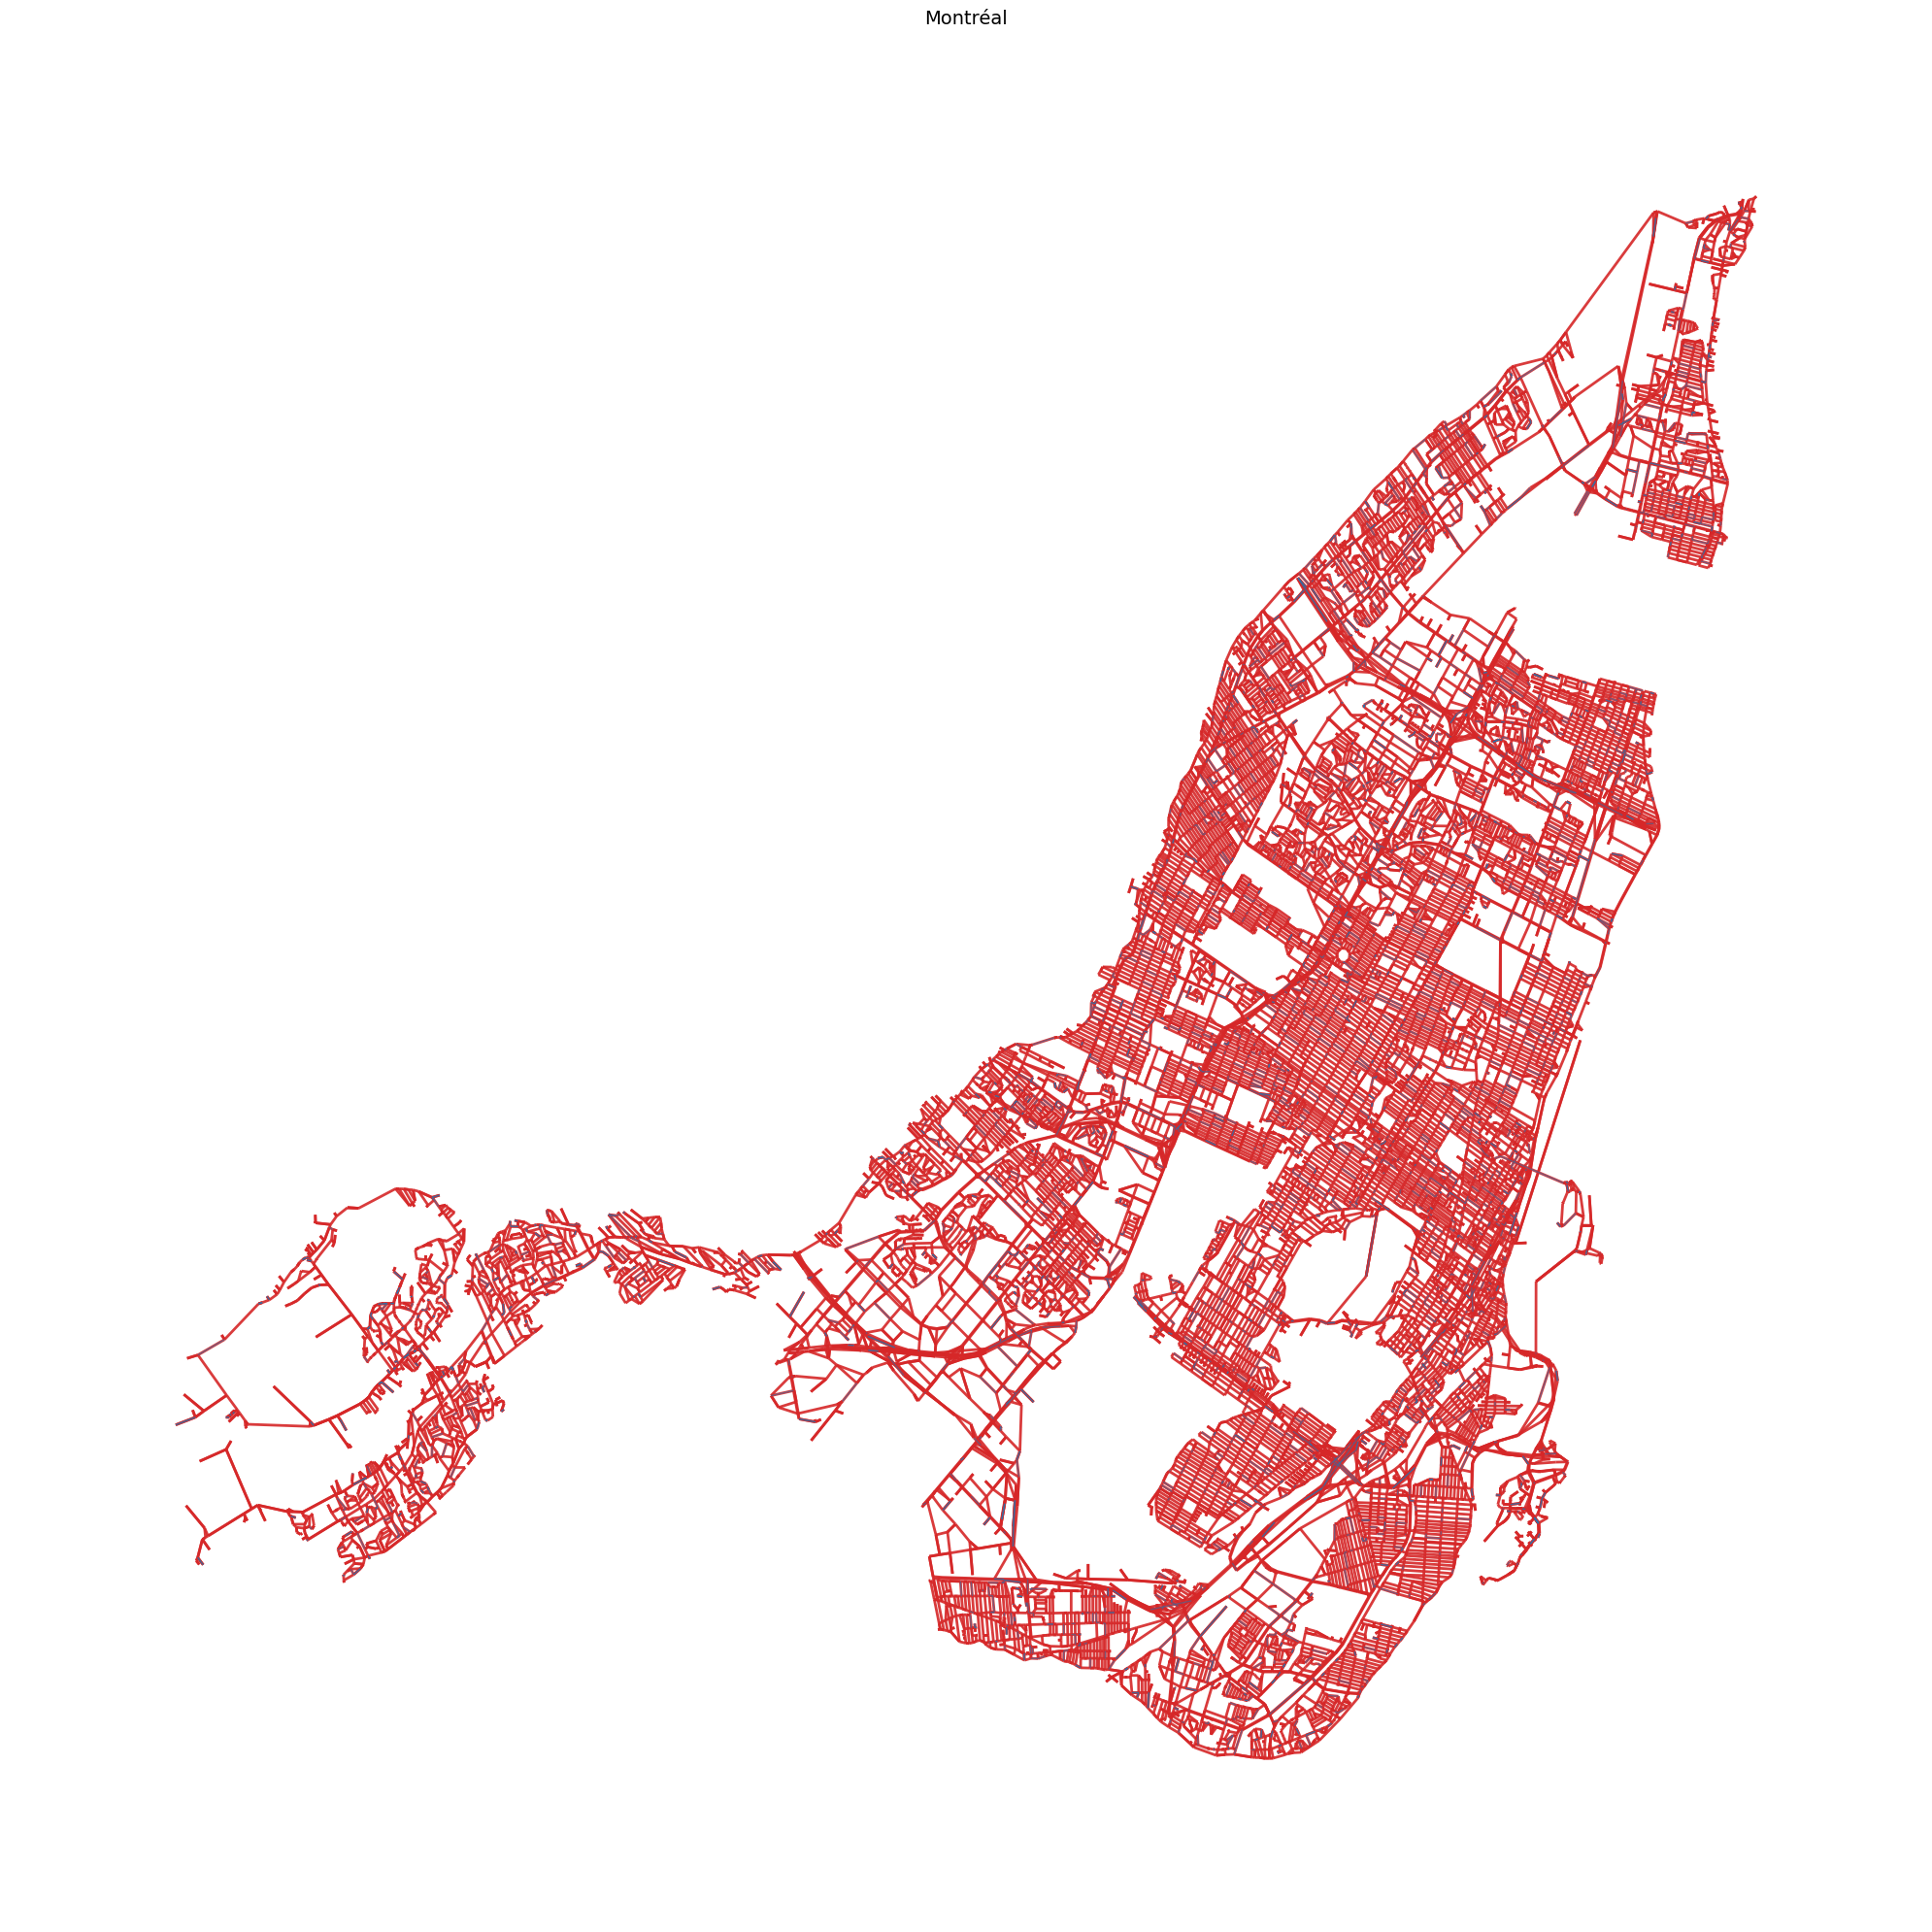

In [27]:
def affiche(G_aug, arrondissement):

    pos = {node: (data['x'], data['y']) for node, data in G_aug.nodes(data=True)}
    cir = list(nx.eulerian_circuit(G_aug))
    
    def is_valid_edge(u, v, d=0):
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        return (x1 != x2) and (y1 != y2)

    edges_to_draw = [(u, v) for u, v, d in G_aug.edges(data=True) if is_valid_edge(u, v, d)]
    new_cir = [(u, v) for u, v in cir if is_valid_edge(u, v)]

    plt.figure(figsize=(20, 20))

    nx.draw_networkx_nodes(G_aug, pos, node_color="tab:blue", node_size=0, alpha=0.5)

    nx.draw_networkx_edges(G_aug, pos, edgelist=edges_to_draw, width=0.5, alpha=0.1, edge_color="gray")

    nx.draw_networkx_edges(G_aug, pos, edgelist=new_cir, width=2, alpha=0.9, edge_color="tab:red")

    nx.draw_networkx_edges(
    G_aug,
    pos,
    edgelist=snow_edges,
    width=1,
    alpha=0.5,
    edge_color="tab:blue",
    )

    plt.title("Montréal", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

affiche(G_aug,snow_edges)